In [1]:
import numpy as np 
import pandas as pd 
import os
import copy
import shutil
import random
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR

import torchvision.models as models
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

from sklearn.metrics import (
    confusion_matrix, accuracy_score,
    precision_score, recall_score, f1_score, classification_report
)

print('start')

# ============================================================
# 1. DATASET SETUP (70/10/20 Split with Robust Path Handling)
# ============================================================

IMG_SIZE   = 224
BATCH_SIZE = 32

# Path to your dataset
input_path   = "/kaggle/input/datasets/ashrafhussanbabor/coin-dataset-with-separated/Coin_dataset_divided"
working_path = "/kaggle/working/coin_dataset"

def prepare_data(src, dest):
    if os.path.exists(dest):
        shutil.rmtree(dest)
    
    # Get only valid class directories (ignore hidden files like .ipynb_checkpoints)
    classes = [d for d in os.listdir(src) if os.path.isdir(os.path.join(src, d))]
    print(f"Found classes: {classes}")

    for cls in classes:
        cls_src_path = os.path.join(src, cls)
        images = [f for f in os.listdir(cls_src_path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
        
        random.seed(42)
        random.shuffle(images)
        
        # 70% Train, 10% Val, 20% Test
        train_idx = int(len(images) * 0.70)
        val_idx   = int(len(images) * 0.80)
        
        for i, img in enumerate(images):
            if i < train_idx:
                split = 'train'
            elif i < val_idx:
                split = 'valid'
            else:
                split = 'test'
            
            # Create destination folder dynamically
            target_dir = os.path.join(dest, split, cls)
            os.makedirs(target_dir, exist_ok=True)
            
            src_file = os.path.join(cls_src_path, img)
            dst_file = os.path.join(target_dir, img)
            
            shutil.copy(src_file, dst_file)

print("🔄 Organizing dataset (70/10/20)...")
prepare_data(input_path, working_path)
print("✅ Dataset prepared!")

train_dir = os.path.join(working_path, "train")
val_dir   = os.path.join(working_path, "valid")
test_dir  = os.path.join(working_path, "test")

# --- Rest of the code remains exactly the same as your request ---

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

train_dataset = datasets.ImageFolder(train_dir, transform=train_transform)
val_dataset   = datasets.ImageFolder(val_dir,   transform=val_transform)
test_dataset  = datasets.ImageFolder(test_dir,  transform=val_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

NUM_CLASSES = len(train_dataset.classes)
CLASS_NAMES = train_dataset.classes

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ============================================================
# MODEL DEFINITIONS (As per your original code)
# ============================================================

class ChannelAttention(nn.Module):
    def __init__(self, in_channels, reduction_ratio=16):
        super().__init__()
        mid = max(in_channels // reduction_ratio, 1)
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.max_pool = nn.AdaptiveMaxPool2d(1)
        self.mlp = nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_channels, mid, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(mid, in_channels, bias=False)
        )
        self.sigmoid = nn.Sigmoid()
    def forward(self, x):
        avg_out = self.mlp(self.avg_pool(x))
        max_out = self.mlp(self.max_pool(x))
        scale   = self.sigmoid(avg_out + max_out)
        return x * scale.unsqueeze(-1).unsqueeze(-1)

class SpatialAttention(nn.Module):
    def __init__(self, kernel_size=7):
        super().__init__()
        self.conv    = nn.Conv2d(2, 1, kernel_size, padding=kernel_size // 2, bias=False)
        self.sigmoid = nn.Sigmoid()
    def forward(self, x):
        avg_out = x.mean(dim=1, keepdim=True)
        max_out = x.max(dim=1, keepdim=True)[0]
        scale   = self.sigmoid(self.conv(torch.cat([avg_out, max_out], dim=1)))
        return x * scale

class CBAM(nn.Module):
    def __init__(self, in_channels, reduction_ratio=16, spatial_kernel=7):
        super().__init__()
        self.channel_att = ChannelAttention(in_channels, reduction_ratio)
        self.spatial_att = SpatialAttention(spatial_kernel)
    def forward(self, x):
        x = self.channel_att(x)
        x = self.spatial_att(x)
        return x

class FeatureAlignmentAdapter(nn.Module):
    def __init__(self, student_channels: int, teacher_channels: int):
        super().__init__()
        self.proj = nn.Conv2d(student_channels, teacher_channels, kernel_size=1, bias=False)
        self.bn   = nn.BatchNorm2d(teacher_channels)
    def forward(self, x):
        return self.bn(self.proj(x))

class CustomHead(nn.Module):
    def __init__(self, in_features: int, num_classes: int, hidden_dim: int = 256, dropout_p: float = 0.3):
        super().__init__()
        self.head = nn.Sequential(
            nn.Linear(in_features, hidden_dim, bias=False),
            nn.BatchNorm1d(hidden_dim),
            nn.GELU(),
            nn.Dropout(p=dropout_p),
            nn.Linear(hidden_dim, num_classes)
        )
    def forward(self, x):
        return self.head(x)

class CBAMShuffleNet(nn.Module):
    STUDENT_FEAT_CH = 464
    TEACHER_FEAT_CH = 512
    def __init__(self, num_classes: int, head_hidden_dim: int = 256, head_dropout: float  = 0.3):
        super().__init__()
        base = models.shufflenet_v2_x1_0(weights=models.ShuffleNet_V2_X1_0_Weights.IMAGENET1K_V1)
        self.conv1, self.maxpool, self.stage2, self.stage3, self.stage4, self.conv5 = \
            base.conv1, base.maxpool, base.stage2, base.stage3, base.stage4, base.conv5
        self.cbam2, self.cbam3, self.cbam4 = CBAM(116), CBAM(232), CBAM(464)
        self.align_adapter = FeatureAlignmentAdapter(self.STUDENT_FEAT_CH, self.TEACHER_FEAT_CH)
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.head = CustomHead(1024, num_classes, head_hidden_dim, head_dropout)
    def forward(self, x):
        x = self.maxpool(self.conv1(x))
        x = self.cbam2(self.stage2(x))
        x = self.cbam3(self.stage3(x))
        x = self.cbam4(self.stage4(x))
        aligned_feat = self.align_adapter(x)
        x = self.pool(self.conv5(x)).flatten(1)
        logits = self.head(x)
        return (logits, aligned_feat) if self.training else logits

def build_teacher(num_classes: int):
    model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    return model.to(device)

def build_student(num_classes: int):
    return CBAMShuffleNet(num_classes).to(device)

teacher, student = build_teacher(NUM_CLASSES), build_student(NUM_CLASSES)
teacher_feat_store = {}
def _teacher_hook(module, input, output): teacher_feat_store['layer4'] = output.detach()
teacher.layer4.register_forward_hook(_teacher_hook)

# ============================================================
# LOSS & TRAINING
# ============================================================

class CombinedKDLoss(nn.Module):
    def __init__(self, temperature=4.0, alpha=0.4, lambda_feat=0.1):
        super().__init__()
        self.T, self.alpha, self.lambda_feat = temperature, alpha, lambda_feat
        self.ce, self.mse = nn.CrossEntropyLoss(), nn.MSELoss()
    @staticmethod
    def _norm(t):
        mu, std = t.mean(dim=[1, 2, 3], keepdim=True), t.std(dim=[1, 2, 3], keepdim=True).clamp(min=1e-6)
        return (t - mu) / std
    def forward(self, student_logits, teacher_logits, labels, student_feat, teacher_feat):
        loss_ce = self.ce(student_logits, labels)
        s_soft, t_soft = F.log_softmax(student_logits/self.T, dim=1), F.softmax(teacher_logits/self.T, dim=1)
        loss_kd = F.kl_div(s_soft, t_soft, reduction="batchmean") * (self.T ** 2)
        loss_feat = self.mse(self._norm(student_feat), self._norm(teacher_feat))
        return (self.alpha * loss_ce + (1-self.alpha) * loss_kd + self.lambda_feat * loss_feat), loss_ce.item(), loss_kd.item(), loss_feat.item()

class EarlyStopping:
    def __init__(self, patience=10, min_delta=1e-4):
        self.patience, self.min_delta, self.best_loss, self.counter, self.best_state = patience, min_delta, None, 0, None
    def step(self, val_loss, model):
        if self.best_loss is None or val_loss < self.best_loss - self.min_delta:
            self.best_loss, self.counter, self.best_state = val_loss, 0, copy.deepcopy(model.state_dict())
        else: self.counter += 1
        return self.counter >= self.patience
    def restore_best(self, model): model.load_state_dict(self.best_state)

def evaluate(model, loader):
    model.eval()
    criterion, total_loss, correct, total = nn.CrossEntropyLoss(), 0.0, 0, 0
    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            out = model(imgs)
            total_loss += criterion(out, labels).item() * imgs.size(0)
            correct += (out.argmax(1) == labels).sum().item(); total += imgs.size(0)
    return total_loss / total, correct / total

EPOCHS, PATIENCE, LR_TEACHER, LR_STUDENT = 100, 12, 1e-3, 1e-3
TEMPERATURE, ALPHA, LAMBDA_FEAT = 4.0, 0.4, 0.1

print("\nPHASE 1 — Teacher Training")
t_opt = AdamW(teacher.parameters(), lr=LR_TEACHER, weight_decay=1e-4)
t_sch = CosineAnnealingLR(t_opt, T_max=EPOCHS)
t_es = EarlyStopping(patience=PATIENCE)
for epoch in range(1, EPOCHS + 1):
    teacher.train()
    rl, c, t = 0.0, 0, 0
    for imgs, labels in train_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        t_opt.zero_grad(); out = teacher(imgs); loss = nn.CrossEntropyLoss()(out, labels)
        loss.backward(); t_opt.step()
        rl += loss.item() * imgs.size(0); c += (out.argmax(1) == labels).sum().item(); t += imgs.size(0)
    t_sch.step(); vl, va = evaluate(teacher, val_loader)
    print(f"Epoch {epoch:02d} | Train Acc: {c/t:.4f} | Val Acc: {va:.4f}")
    if t_es.step(vl, teacher): break
t_es.restore_best(teacher)

print("\nPHASE 2 — Student KD Training")
s_opt = AdamW(student.parameters(), lr=LR_STUDENT, weight_decay=1e-4)
s_sch = CosineAnnealingLR(s_opt, T_max=EPOCHS)
kd_fn = CombinedKDLoss(temperature=TEMPERATURE, alpha=ALPHA, lambda_feat=LAMBDA_FEAT)
s_es = EarlyStopping(patience=PATIENCE)
teacher.eval()
for epoch in range(1, EPOCHS + 1):
    student.train()
    rl, c, t = 0.0, 0, 0
    for imgs, labels in train_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        with torch.no_grad(): t_logits = teacher(imgs); t_feat = teacher_feat_store['layer4']
        s_opt.zero_grad(); s_logits, s_feat = student(imgs)
        loss, _, _, _ = kd_fn(s_logits, t_logits, labels, s_feat, t_feat)
        loss.backward(); s_opt.step()
        rl += loss.item() * imgs.size(0); c += (s_logits.argmax(1) == labels).sum().item(); t += imgs.size(0)
    s_sch.step(); vl, va = evaluate(student, val_loader)
    print(f"Epoch {epoch:02d} | Train Acc: {c/t:.4f} | Val Acc: {va:.4f}")
    if s_es.step(vl, student): break
s_es.restore_best(student)

torch.save(teacher.state_dict(), "/kaggle/working/teacher_resnet18.pth")
torch.save(student.state_dict(), "/kaggle/working/student_full_proposed.pth")

def full_evaluation(model, loader, name):
    model.eval(); all_p, all_l = [], []
    with torch.no_grad():
        for imgs, labels in loader:
            all_p.extend(model(imgs.to(device)).argmax(1).cpu().numpy())
            all_l.extend(labels.numpy())
    print(f"\n--- {name} Results ---")
    print(classification_report(all_l, all_p, target_names=CLASS_NAMES))

full_evaluation(teacher, test_loader, "Teacher (Test)")
full_evaluation(student, test_loader, "Student (Test)")

start
🔄 Organizing dataset (70/10/20)...
Found classes: ['2tk', '1tk', '5tk']
✅ Dataset prepared!
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 202MB/s]


Downloading: "https://download.pytorch.org/models/shufflenetv2_x1-5666bf0f80.pth" to /root/.cache/torch/hub/checkpoints/shufflenetv2_x1-5666bf0f80.pth


100%|██████████| 8.79M/8.79M [00:00<00:00, 120MB/s]


PHASE 1 — Teacher Training


Epoch 01 | Train Acc: 0.9703 | Val Acc: 0.7680
Epoch 02 | Train Acc: 0.9921 | Val Acc: 1.0000
Epoch 03 | Train Acc: 0.9930 | Val Acc: 0.9756
Epoch 04 | Train Acc: 0.9980 | Val Acc: 1.0000
Epoch 05 | Train Acc: 0.9987 | Val Acc: 1.0000
Epoch 06 | Train Acc: 0.9999 | Val Acc: 1.0000
Epoch 07 | Train Acc: 0.9999 | Val Acc: 1.0000
Epoch 08 | Train Acc: 0.9999 | Val Acc: 1.0000
Epoch 09 | Train Acc: 0.9950 | Val Acc: 0.4971
Epoch 10 | Train Acc: 0.9891 | Val Acc: 1.0000
Epoch 11 | Train Acc: 0.9990 | Val Acc: 1.0000
Epoch 12 | Train Acc: 0.9997 | Val Acc: 1.0000
Epoch 13 | Train Acc: 0.9994 | Val Acc: 1.0000
Epoch 14 | Train Acc: 0.9985 | Val Acc: 0.9990
Epoch 15 | Train Acc: 0.9948 | Val Acc: 1.0000
Epoch 16 | Train Acc: 0.9999 | Val Acc: 1.0000
Epoch 17 | Train Acc: 0.9968 | Val Acc: 1.0000

PHASE 2 — Student KD Training
Epoch 01 | Train Acc: 0.9872 | Val Acc: 1.0000
Epoch 02 | Train Acc: 0.9994 | Val Acc: 1.0000
Epoch 03 | Train Acc: 0.9962 | Val Acc: 0.9990
Epoch 04 | Train Acc: 0.9999 

📊 Generating Confusion Matrices...


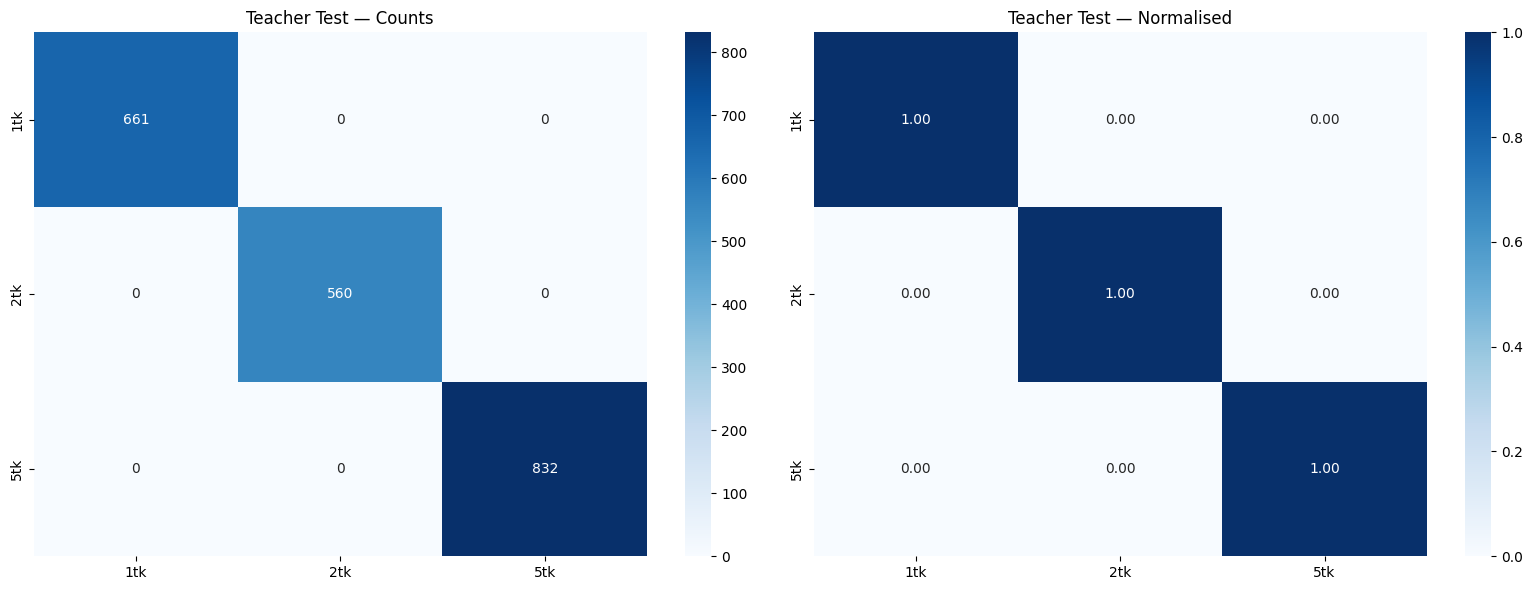

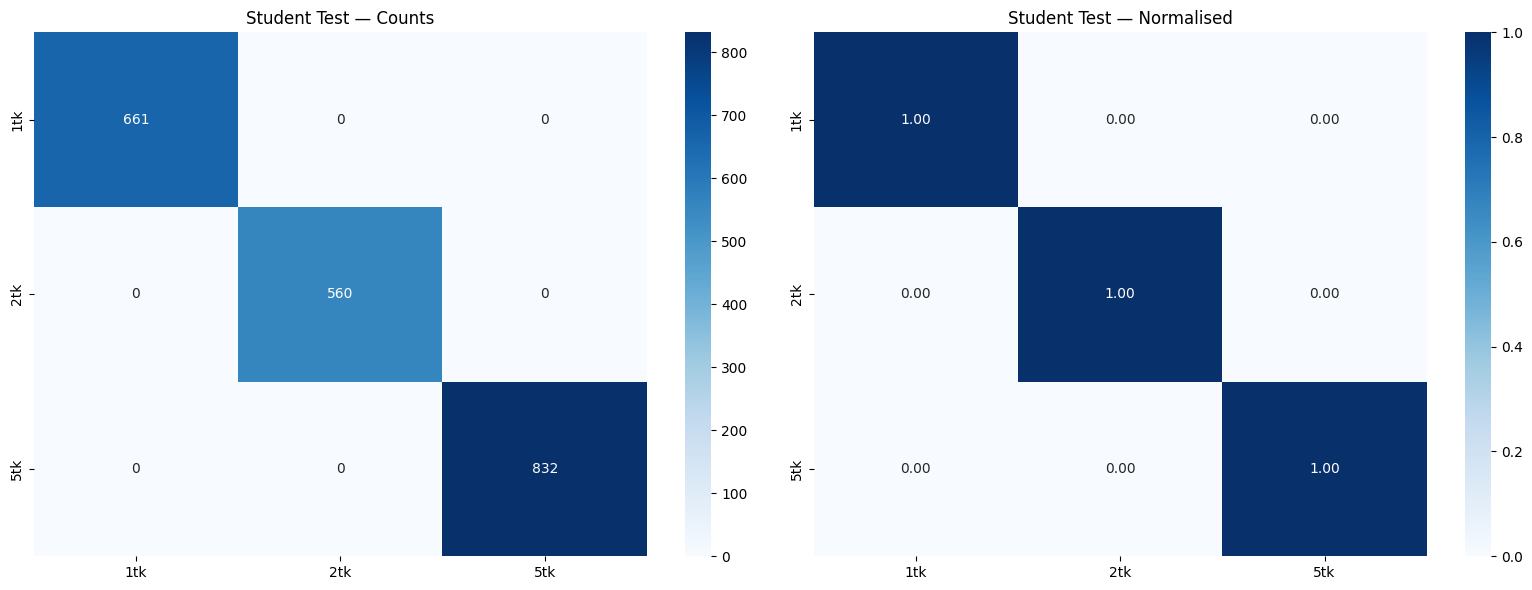


  📋  TEACHER vs PROPOSED STUDENT — Final Comparison

  [Validation Set]
  Metric          Teacher        Student
  --------------------------------------
  Accuracy         1.0000         1.0000
  Precision        1.0000         1.0000
  Recall           1.0000         1.0000
  F1               1.0000         1.0000

  [Test Set]
  Metric          Teacher        Student
  --------------------------------------
  Accuracy         1.0000         1.0000
  Precision        1.0000         1.0000
  Recall           1.0000         1.0000
  F1               1.0000         1.0000

🏗️  Proposed Student Architecture Summary:
   Backbone   : ShuffleNetV2-x1.0 (pretrained)
   Attention  : CBAM (Channel & Spatial)
   Feat Align : FeatureAlignmentAdapter (464→512)
   Head       : Linear(1024→256)→BN→GELU→Drop→Linear(256→3)
   Student Total Params: 1,790,949
Skipping curves for Teacher: No history found.
Skipping curves for Student: No history found.


In [4]:
import seaborn as sns
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, classification_report

# ============================================================
# 1. LEARNING CURVES (Requires lists from training)
# ============================================================
def plot_curves(train_losses, val_losses, train_accs, val_accs, title_prefix, save_path):
    if len(train_losses) == 0:
        print(f"Skipping curves for {title_prefix}: No history found.")
        return
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    ep = range(1, len(train_losses) + 1)
    axes[0].plot(ep, train_losses, label="Train Loss", linewidth=2)
    axes[0].plot(ep, val_losses,   label="Val Loss",   linewidth=2)
    axes[0].set_title(f"{title_prefix} — Loss")
    axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss")
    axes[0].legend(); axes[0].grid(True, alpha=0.3)
    axes[1].plot(ep, train_accs, label="Train Acc", linewidth=2)
    axes[1].plot(ep, val_accs,   label="Val Acc",   linewidth=2)
    axes[1].set_title(f"{title_prefix} — Accuracy")
    axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy")
    axes[1].legend(); axes[1].grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(save_path, dpi=150)
    plt.show()

# ============================================================
# 2. CONFUSION MATRIX FUNCTION
# ============================================================
def plot_custom_cm(model, loader, title, save_path):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for imgs, labels in loader:
            imgs = imgs.to(device)
            out = model(imgs)
            # Handle student returning tuple in train but single tensor in eval
            logits = out[0] if isinstance(out, tuple) else out
            all_preds.extend(logits.argmax(dim=1).cpu().numpy())
            all_labels.extend(labels.numpy())
            
    cm = confusion_matrix(all_labels, all_preds)
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=axes[0])
    axes[0].set_title(f"{title} — Counts")
    sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="Blues", xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=axes[1])
    axes[1].set_title(f"{title} — Normalised")
    plt.tight_layout()
    plt.savefig(save_path, dpi=150)
    plt.show()

# ============================================================
# 3. COMPARISON TABLE GENERATOR
# ============================================================
def get_metrics_dict(model, loader):
    model.eval()
    pl, ll = [], []
    with torch.no_grad():
        for imgs, labels in loader:
            out = model(imgs.to(device))
            logits = out[0] if isinstance(out, tuple) else out
            pl.extend(logits.argmax(1).cpu().numpy())
            ll.extend(labels.numpy())
    p, l = np.array(pl), np.array(ll)
    return {
        "Accuracy" : accuracy_score(l, p),
        "Precision": precision_score(l, p, average="weighted", zero_division=0),
        "Recall"   : recall_score(l, p,    average="weighted", zero_division=0),
        "F1"       : f1_score(l, p,        average="weighted", zero_division=0),
    }

# --- EXECUTION ---

# 1. Plot Confusion Matrices
print("📊 Generating Confusion Matrices...")
plot_custom_cm(teacher, test_loader, "Teacher Test", "/kaggle/working/cm_teacher_test.png")
plot_custom_cm(student, test_loader, "Student Test", "/kaggle/working/cm_student_test.png")

# 2. Print Comparison Table
print("\n" + "="*55)
print("  📋  TEACHER vs PROPOSED STUDENT — Final Comparison")
print("="*55)
for split_name, loader in [("Validation", val_loader), ("Test", test_loader)]:
    tm = get_metrics_dict(teacher, loader)
    sm = get_metrics_dict(student, loader)
    print(f"\n  [{split_name} Set]")
    print(f"  {'Metric':<12} {'Teacher':>10} {'Student':>14}")
    print(f"  {'-'*38}")
    for k in tm:
        print(f"  {k:<12} {tm[k]:>10.4f} {sm[k]:>14.4f}")

# 3. Architecture Summary
print("\n🏗️  Proposed Student Architecture Summary:")
print(f"   Backbone   : ShuffleNetV2-x1.0 (pretrained)")
print(f"   Attention  : CBAM (Channel & Spatial)")
print(f"   Feat Align : FeatureAlignmentAdapter (464→512)")
print(f"   Head       : Linear(1024→256)→BN→GELU→Drop→Linear(256→{NUM_CLASSES})")
print(f"   Student Total Params: {sum(p.numel() for p in student.parameters()):,}")

# 4. Attempt to plot curves (only works if history lists exist)
# If you didn't save them in the last cell, these will skip silently
plot_curves(locals().get('teacher_train_losses', []), locals().get('teacher_val_losses', []),
            locals().get('teacher_train_accs', []), locals().get('teacher_val_accs', []),
            "Teacher", "/kaggle/working/teacher_curves.png")

plot_curves(locals().get('student_train_losses', []), locals().get('student_val_losses', []),
            locals().get('student_train_accs', []), locals().get('student_val_accs', []),
            "Student", "/kaggle/working/student_curves.png")